# Sentiment Analysis using Twitter Dataset

## Introduction

Sentiment analysis is a Natural Language Processing (NLP) technique used to identify the emotional tone behind text data.

In this project we analyze tweets and classify them into three categories:

* Positive
* Negative
* Neutral

The dataset used is the Twitter Sentiment Dataset from Kaggle.

## Objectives

• Perform sentiment classification on tweet data
• Apply Natural Language Processing techniques
• Train a machine learning model for sentiment prediction
• Visualize sentiment distribution


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Twitter_Data.csv to Twitter_Data.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
data = pd.read_csv("Twitter_Data.csv")
data.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


## Understanding the Dataset

The dataset contains tweets along with sentiment labels.

Columns:
• clean_text – tweet content
• category – sentiment label

Sentiment labels:

* -1 → Negative
* 0 → Neutral
* 1 → Positive


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


In [ ]:
data.isnull().sum()

,0
clean_text,4
category,7


In [ ]:
data = data.dropna()

## Sentiment Distribution

Understanding how many tweets belong to each sentiment category helps us understand the dataset balance.


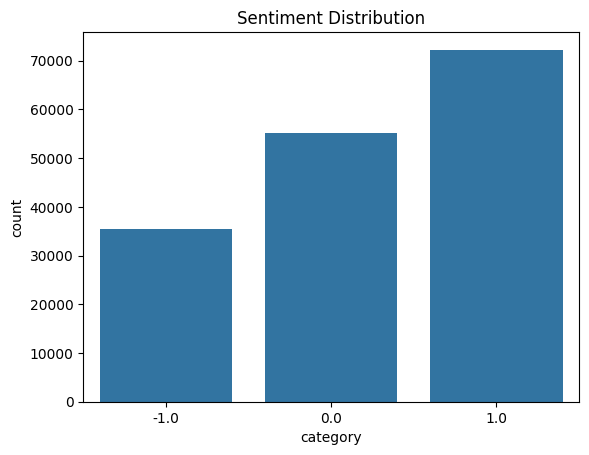

In [ ]:
sns.countplot(x=data["category"])
plt.title("Sentiment Distribution")
plt.show()

## Feature Engineering

Machine learning models cannot directly understand text data. Therefore we convert text into numerical form using a technique called Bag of Words.

We use CountVectorizer to transform tweets into numerical features.


In [ ]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(data["clean_text"])
y = data["category"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
 predictions = model.predict(X_test)

## Model Evaluation

After training the model, we evaluate its performance using accuracy score and classification metrics.


In [ ]:
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.7482665521261582


In [ ]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

        -1.0       0.74      0.63      0.68      7152
         0.0       0.91      0.61      0.73     11067
         1.0       0.69      0.91      0.78     14375

    accuracy                           0.75     32594
   macro avg       0.78      0.72      0.73     32594
weighted avg       0.77      0.75      0.74     32594



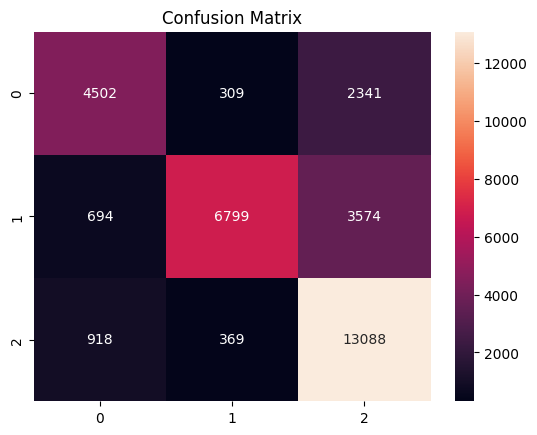

In [ ]:
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()


## Conclusion

In this project, we performed sentiment analysis on Twitter data.

Steps performed:

• Loaded and explored the dataset

• Cleaned the data and handled missing values

• Converted text into numerical features

• Trained a machine learning model

• Evaluated the model using accuracy and classification metrics

The sentiment analysis model successfully classifies tweets into positive, negative, and neutral sentiments.
